In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [ ]:
from wordcloud import WordCloud

In [ ]:
import pandas as pd

df = pd.read_csv("netflix1.csv")
data=df.copy()

In [ ]:
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
df.shape


(8790, 10)

In [ ]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
df.describe()


,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.describe(include='object')

,show_id,type,title,director,country,date_added,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790,8790,8790
unique,8790,2,8787,4528,86,1713,14,220,513
top,s8786,Movie,09-Feb,Not Given,United States,01-01-2020,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,3205,1791,362


In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
for col in data.columns:
    print(col)
    print(data[col].nunique())
    print("-"*30)

show_id
8790
------------------------------
type
2
------------------------------
title
8787
------------------------------
director
4528
------------------------------
country
86
------------------------------
date_added
1713
------------------------------
release_year
74
------------------------------
rating
14
------------------------------
duration
220
------------------------------
listed_in
513
------------------------------


In [ ]:
print(data["date_added"].head(20))

0      9/25/2021
1      9/24/2021
2      9/24/2021
3      9/22/2021
4      9/24/2021
5      9/24/2021
6      9/24/2021
7     05-01-2021
8      9/23/2021
9     05-01-2021
10    05-01-2021
11    05-01-2021
12     5/21/2021
13     7/13/2021
14    06-12-2021
15    06-12-2021
16    05-07-2021
17     9/24/2021
18     9/22/2021
19    11/26/2019
Name: date_added, dtype: object


In [ ]:
data["date_added"] = pd.to_datetime(
    data["date_added"],
    format="mixed",
    dayfirst=True
)

In [ ]:
data[data["date_added"].isna()]

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in


In [ ]:
data["year_added"] = data["date_added"].dt.year
data["month_added"] = data["date_added"].dt.month
data["day_added"] = data["date_added"].dt.day

In [ ]:
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,25
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,24
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,24
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,22
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,24


In [ ]:
data.info()
data.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
 10  year_added    8790 non-null   int32         
 11  month_added   8790 non-null   int32         
 12  day_added     8790 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(8)
memory usage: 789.9+ KB


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,day_added
count,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790,8790.000000,8790.000000,8790.000000
unique,8790,2,8787,4528,86,NaN,NaN,14,220,513,NaN,NaN,NaN
top,s8786,Movie,9-Feb,Not Given,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies",NaN,NaN,NaN
freq,1,6126,2,2588,3240,NaN,NaN,3205,1791,362,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2019-05-17 21:44:01.638225408,2014.183163,NaN,NaN,NaN,2018.873606,6.655859,12.500000
min,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,2008.000000,1.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,2018.000000,4.000000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,2019-07-03 00:00:00,2017.000000,NaN,NaN,NaN,2019.000000,7.000000,13.000000
75%,NaN,NaN,NaN,NaN,NaN,2020-08-19 18:00:00,2019.000000,NaN,NaN,NaN,2020.000000,10.000000,20.000000
max,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,2021.000000,12.000000,31.000000


## ***What is the distribution of Movies and TV Shows?***

In [ ]:
data["type"].value_counts()
type_count = data["type"].value_counts()

print(type_count)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


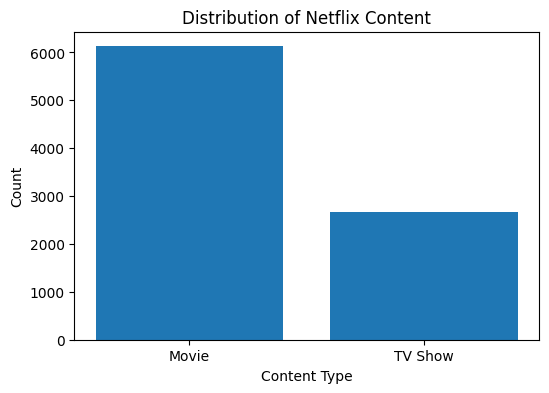

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(type_count.index, type_count.values)

plt.title("Distribution of Netflix Content")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

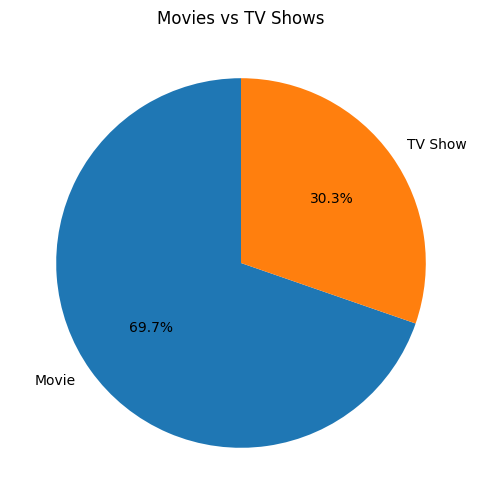

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    type_count.values,
    labels=type_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")

plt.show()

# ***What is the distribution of content ratings on Netflix?***

In [ ]:
rating_count = data["rating"].value_counts()

print(rating_count)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


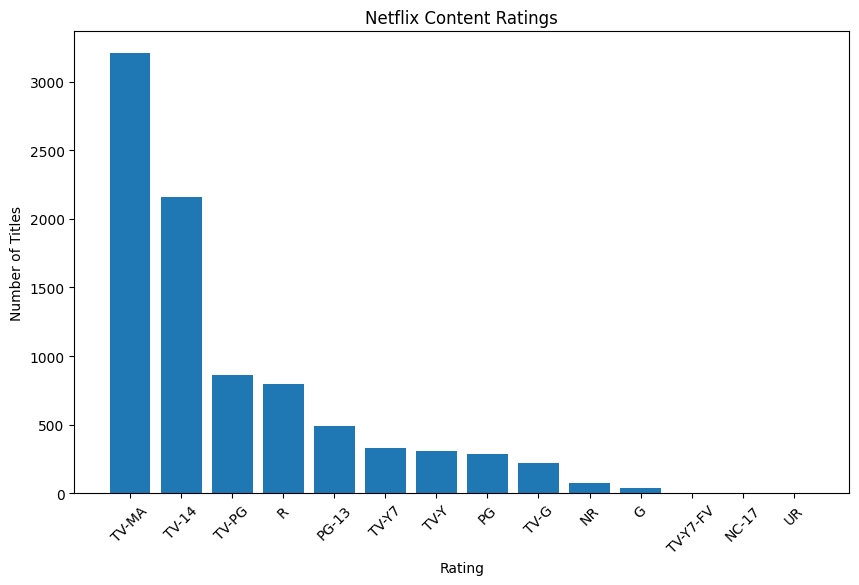

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(rating_count.index, rating_count.values)

plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

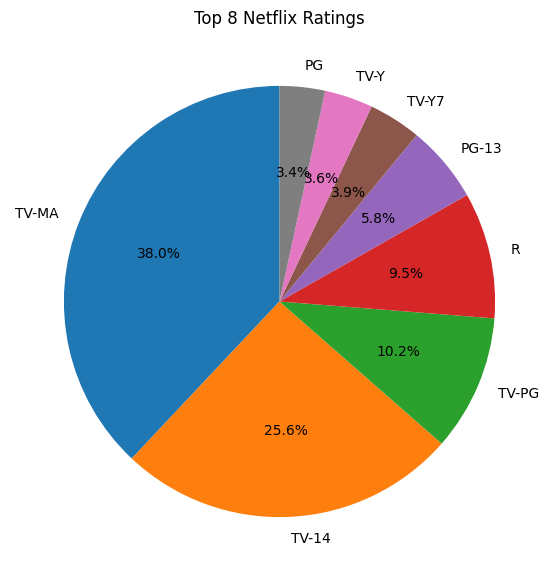

In [ ]:
top_rating = rating_count.head(8)

plt.figure(figsize=(7,7))

plt.pie(
    top_rating.values,
    labels=top_rating.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 8 Netflix Ratings")

plt.show()

# ***Which countries produce the most Netflix content?***

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64


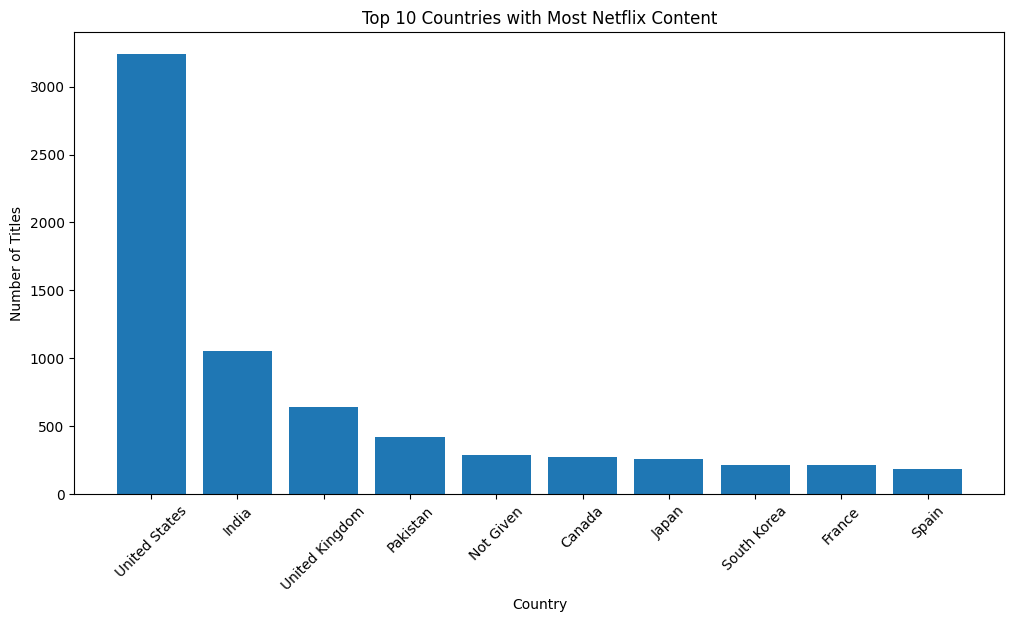

In [ ]:
country_count = data["country"].value_counts()

print(country_count.head(10))

top10_country = country_count.head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(top10_country.index, top10_country.values)

plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [ ]:
top10_percentage = (top10_country / len(data)) * 100

print(top10_percentage.round(2))

country
United States     36.86
India             12.03
United Kingdom     7.26
Pakistan           4.79
Not Given          3.27
Canada             3.08
Japan              2.95
South Korea        2.43
France             2.42
Spain              2.07
Name: count, dtype: float64


# ***How has Netflix's content grown over the years?***

In [ ]:
yearly_content = data["year_added"].value_counts().sort_index()

print(yearly_content)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


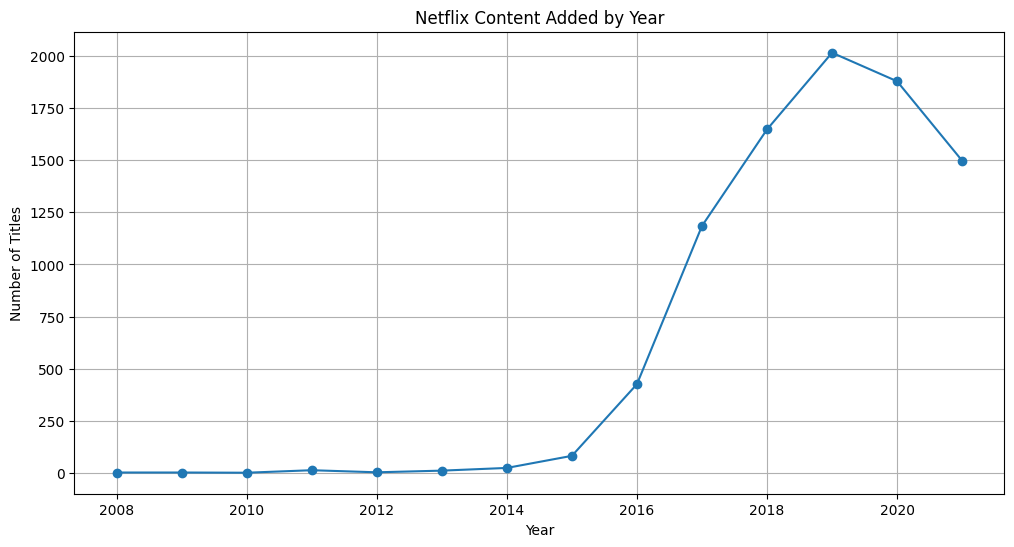

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(yearly_content.index,
         yearly_content.values,
         marker="o")

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

In [ ]:
print("Maximum titles added:", yearly_content.max())
print("Year with maximum additions:",
      yearly_content.idxmax())

Maximum titles added: 2016
Year with maximum additions: 2019


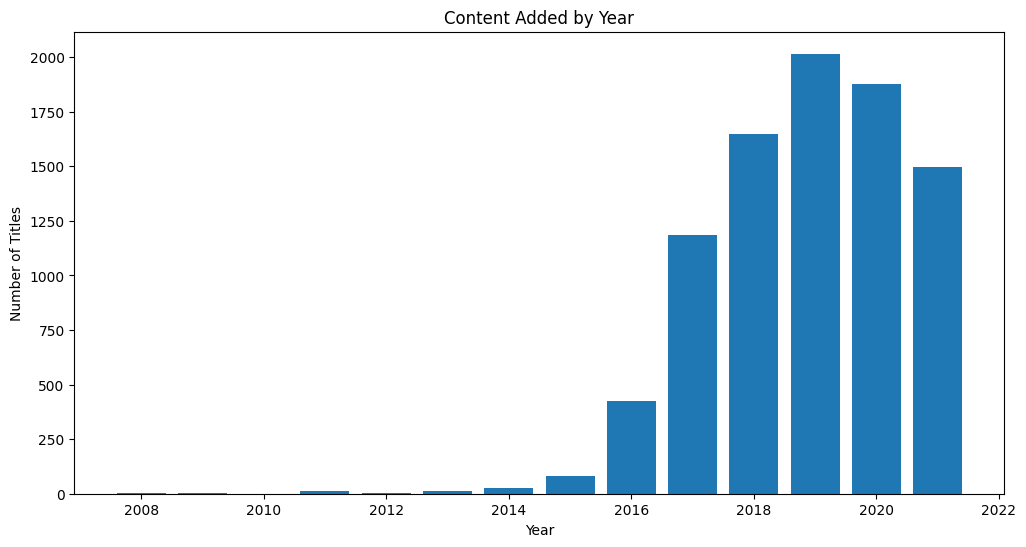

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(yearly_content.index,
        yearly_content.values)

plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

# ***Which month does Netflix add the most content?***

In [ ]:
monthly_content = data["month_added"].value_counts().sort_index()

print(monthly_content)

month_added
1     2507
2      631
3      546
4      604
5      543
6      599
7      568
8      569
9      521
10     555
11     466
12     681
Name: count, dtype: int64


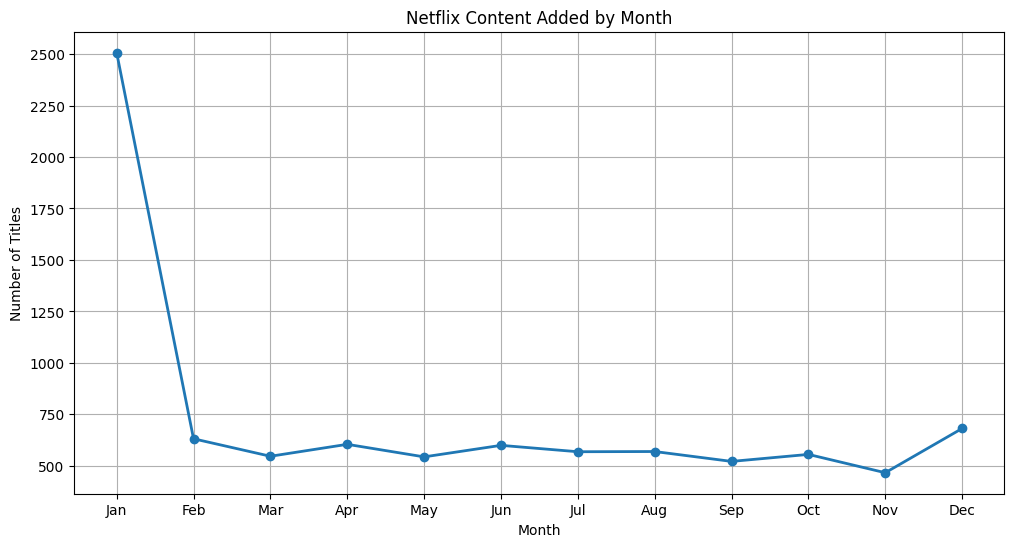

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(monthly_content.index,
         monthly_content.values,
         marker='o',
         linewidth=2)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(
    range(1,13),
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.grid(True)

plt.show()

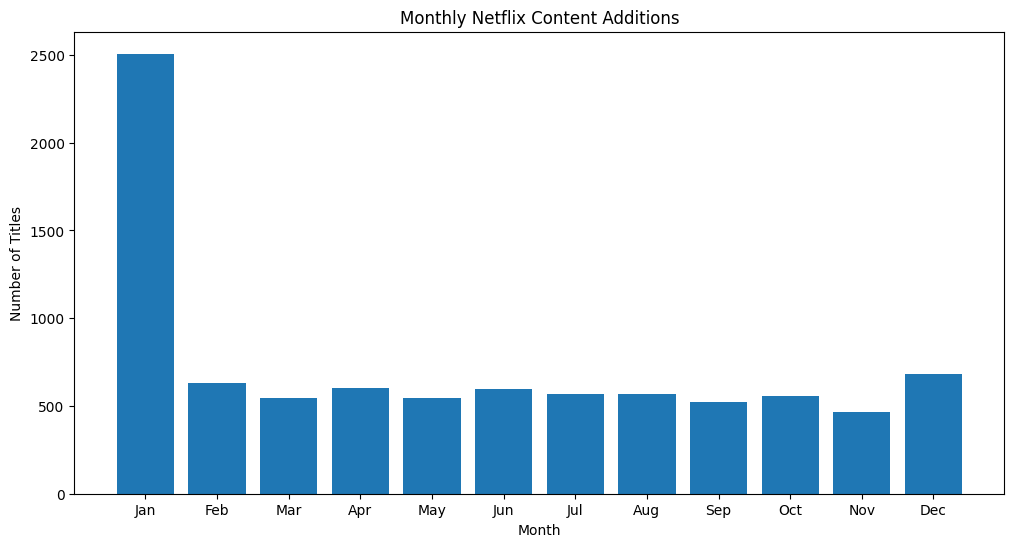

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(monthly_content.index,
        monthly_content.values)

plt.title("Monthly Netflix Content Additions")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(
    range(1,13),
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.show()

In [ ]:
best_month = monthly_content.idxmax()
max_titles = monthly_content.max()

print("Best Month:", best_month)
print("Titles Added:", max_titles)

Best Month: 1
Titles Added: 2507


# ***What are the most popular genres on Netflix?***

In [ ]:
data["listed_in"].head()

,listed_in
0,Documentaries
1,"Crime TV Shows, International TV Shows, TV Act..."
2,"TV Dramas, TV Horror, TV Mysteries"
3,"Children & Family Movies, Comedies"
4,"Dramas, Independent Movies, International Movies"


In [ ]:
genres = data["listed_in"].str.split(", ")


In [ ]:
print(genres.head())

0                                      [Documentaries]
1    [Crime TV Shows, International TV Shows, TV Ac...
2                 [TV Dramas, TV Horror, TV Mysteries]
3                 [Children & Family Movies, Comedies]
4    [Dramas, Independent Movies, International Mov...
Name: listed_in, dtype: object


In [ ]:
all_genres = []

for genre_list in genres:
    all_genres.extend(genre_list)
print(all_genres)

['Documentaries', 'Crime TV Shows', 'International TV Shows', 'TV Action & Adventure', 'TV Dramas', 'TV Horror', 'TV Mysteries', 'Children & Family Movies', 'Comedies', 'Dramas', 'Independent Movies', 'International Movies', 'British TV Shows', 'Reality TV', 'Comedies', 'Dramas', 'Children & Family Movies', 'Comedies', 'Music & Musicals', 'Dramas', 'International Movies', 'Children & Family Movies', 'Music & Musicals', 'Children & Family Movies', 'Comedies', 'Children & Family Movies', 'Comedies', 'Dramas', 'International Movies', 'Music & Musicals', 'Movies', 'Movies', 'Movies', 'Comedies', 'Docuseries', 'Reality TV', 'British TV Shows', 'Crime TV Shows', 'Docuseries', 'Children & Family Movies', "Kids' TV", "Kids' TV", "Kids' TV", 'Children & Family Movies', 'Crime TV Shows', 'International TV Shows', 'TV Action & Adventure', 'Documentaries', 'International Movies', 'Children & Family Movies', 'Crime TV Shows', 'Docuseries', 'International TV Shows', 'Children & Family Movies', 'Come

In [ ]:
genre_count = pd.Series(all_genres).value_counts()

print(genre_count.head(10))

International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


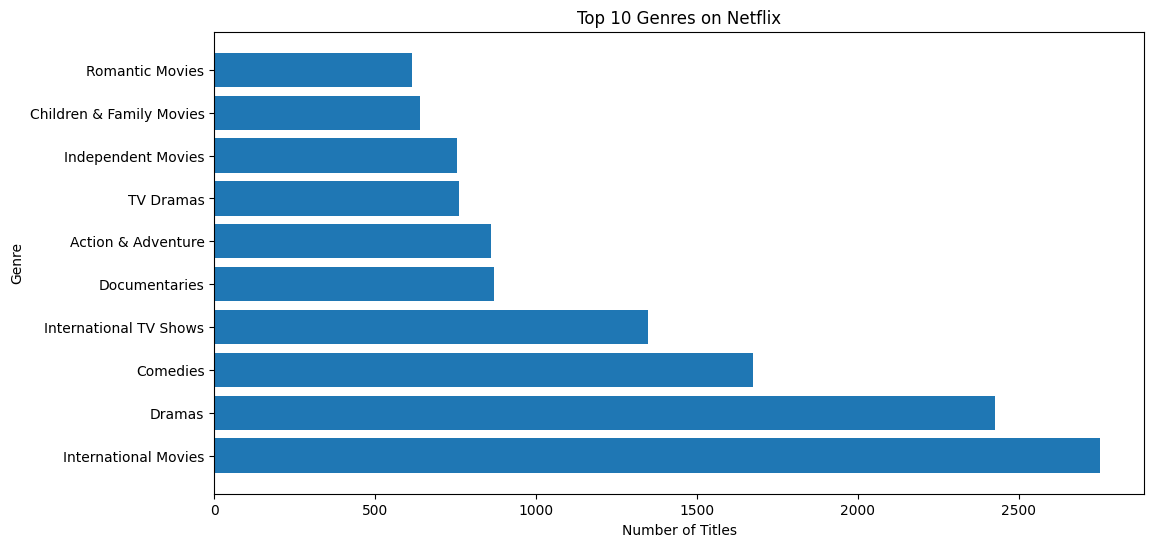

In [ ]:
top10_genres = genre_count.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10_genres.index,
         top10_genres.values)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [ ]:
print("Most Popular Genre:", genre_count.idxmax())
print("Number of Titles:", genre_count.max())

Most Popular Genre: International Movies
Number of Titles: 2752


# ***Who are the Top 10 Directors on Netflix?***

In [ ]:
data["director"].head()

,director
0,Kirsten Johnson
1,Julien Leclercq
2,Mike Flanagan
3,Bruno Garotti
4,Haile Gerima


In [ ]:
director_count = data["director"].value_counts()

print(director_count.head(10))

director
Not Given                 2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Martin Scorsese             12
Name: count, dtype: int64


In [ ]:
top10_directors = director_count.head(10)

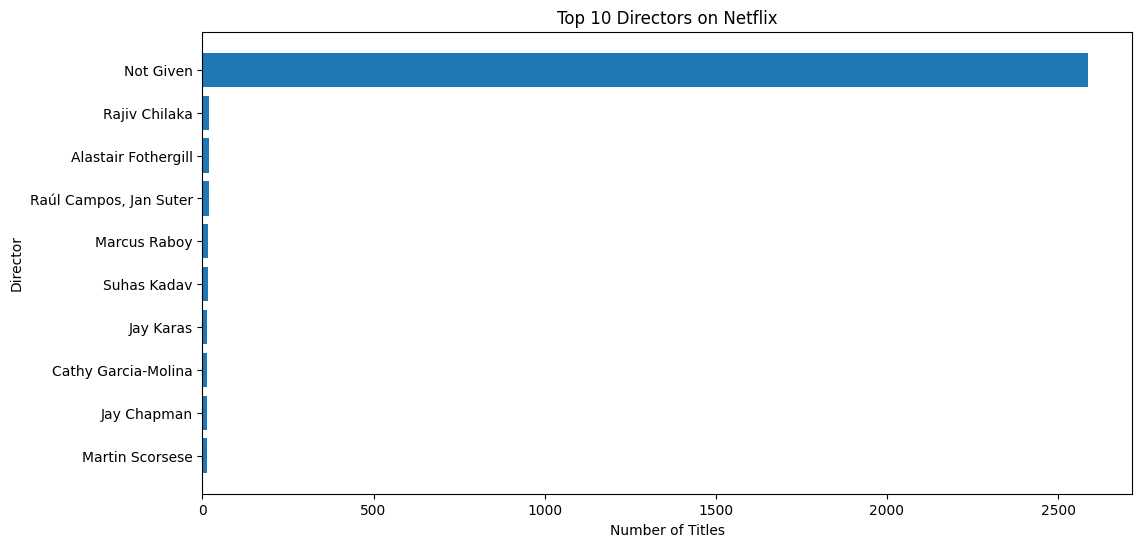

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(top10_directors.index,
         top10_directors.values)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
print("Top Director:", director_count.idxmax())
print("Total Titles:", director_count.max())

Top Director: Not Given
Total Titles: 2588


In [ ]:
movie_directors = (
    data[data["type"] == "Movie"]["director"]
    .value_counts()
    .head(10)
)

print(movie_directors)

director
Not Given                 173
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               15
Jay Karas                  14
Cathy Garcia-Molina        13
Jay Chapman                12
Youssef Chahine            12
Martin Scorsese            12
Name: count, dtype: int64


In [ ]:
tv_directors = (
    data[data["type"] == "TV Show"]["director"]
    .value_counts()
    .head(10)
)

print(tv_directors)

director
Not Given                       2415
Alastair Fothergill               14
Mark Thornton, Todd Kauffman       5
Stan Lathan                        3
Hsu Fu-chun                        2
Rob Seidenglanz                    2
Ken Burns                          2
Shin Won-ho                        2
Iginio Straffi                     2
Mike Flanagan                      1
Name: count, dtype: int64


# ***Movie Duration Analysis***

In [ ]:
movies = data[data["type"] == "Movie"].copy()

In [ ]:
movies["duration"].head()

,duration
0,90 min
3,91 min
4,125 min
6,104 min
7,87 min


In [ ]:
movies["duration"] = movies["duration"].str.replace(" min", "")

In [ ]:
movies["duration"] = movies["duration"].astype(int)

In [ ]:
movies["duration"].dtype

dtype('int64')

In [ ]:
movies["duration"].describe()

,duration
count,6126.000000
mean,99.584884
std,28.283225
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


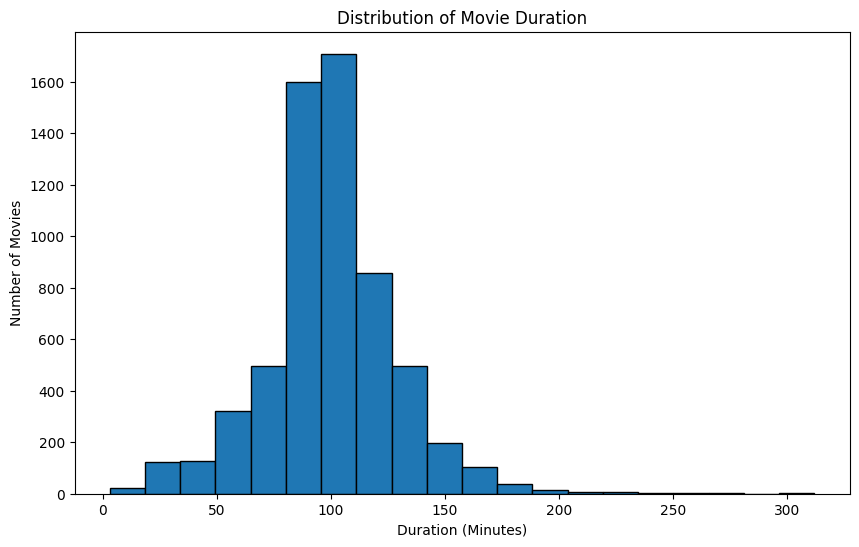

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    movies["duration"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

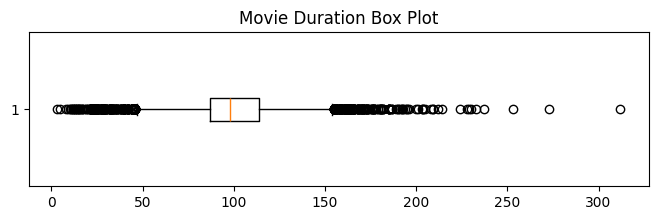

In [ ]:
plt.figure(figsize=(8,2))

plt.boxplot(movies["duration"], vert=False)

plt.title("Movie Duration Box Plot")

plt.show()

In [ ]:
longest_movie = movies.loc[movies["duration"].idxmax()]

print(longest_movie[["title", "duration", "release_year"]])

title           Black Mirror: Bandersnatch
duration                               312
release_year                          2018
Name: 7822, dtype: object


In [ ]:
shortest_movie = movies.loc[movies["duration"].idxmin()]

print(shortest_movie[["title", "duration", "release_year"]])

title           Silent
duration             3
release_year      2014
Name: 2820, dtype: object


# ***Release Year Analysis***

In [ ]:
release_year_count = data["release_year"].value_counts().sort_index()

print(release_year_count)

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


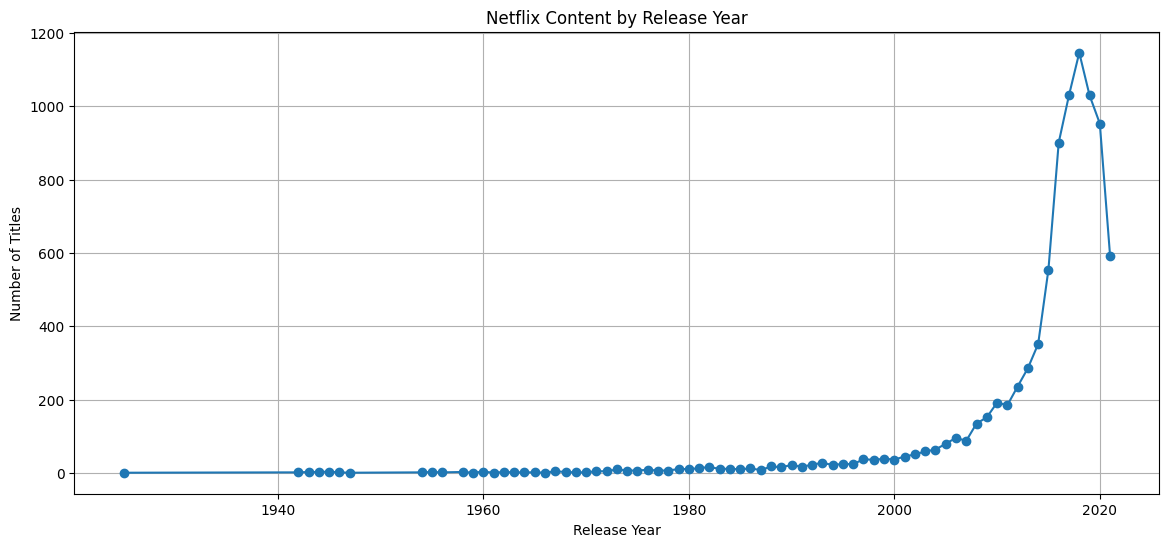

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    release_year_count.index,
    release_year_count.values,
    marker='o'
)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

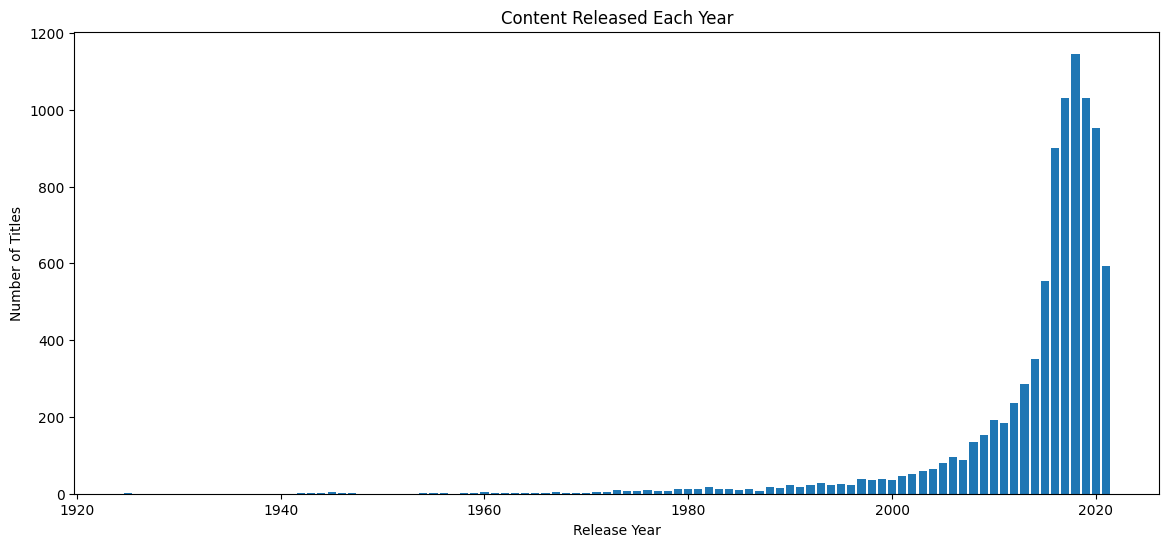

In [ ]:
plt.figure(figsize=(14,6))

plt.bar(
    release_year_count.index,
    release_year_count.values
)

plt.title("Content Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [ ]:
print("Most Common Release Year:", release_year_count.idxmax())
print("Total Titles:", release_year_count.max())

Most Common Release Year: 2018
Total Titles: 1146


In [ ]:
movie_release = (
    data[data["type"]=="Movie"]["release_year"]
    .value_counts()
    .sort_index()
)
tv_release = (
    data[data["type"]=="TV Show"]["release_year"]
    .value_counts()
    .sort_index()
)

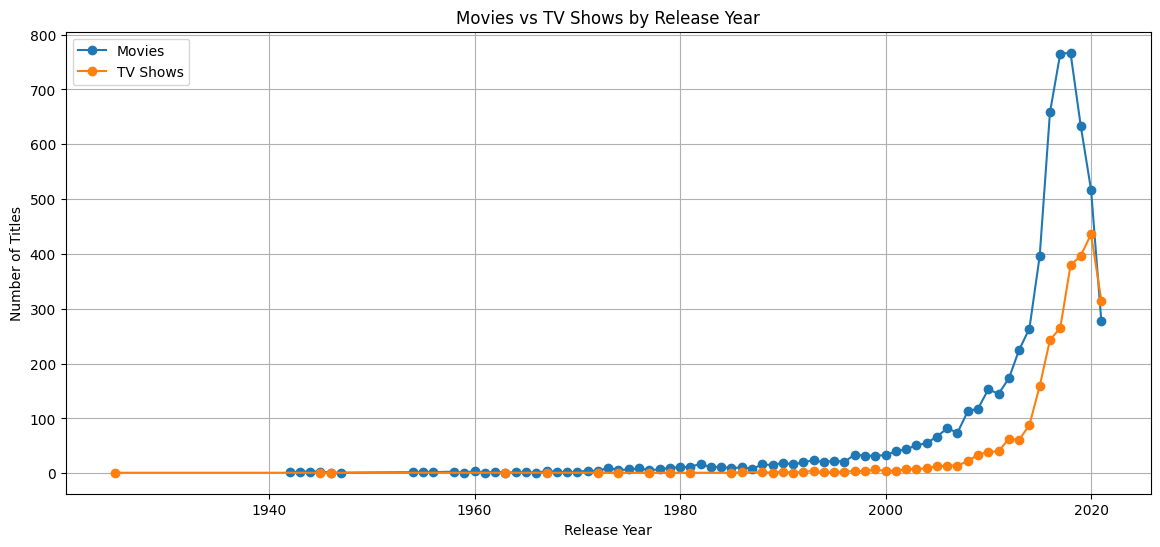

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    movie_release.index,
    movie_release.values,
    label="Movies",
    marker='o'
)

plt.plot(
    tv_release.index,
    tv_release.values,
    label="TV Shows",
    marker='o'
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
top_years = (
    data["release_year"]
    .value_counts()
    .head(10)
)

print(top_years)

release_year
2018    1146
2019    1030
2017    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64


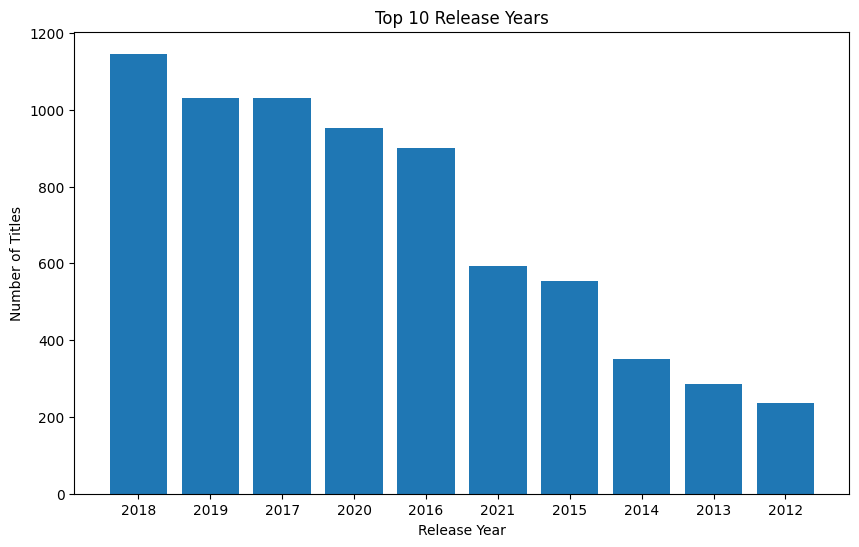

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    top_years.index.astype(str),
    top_years.values
)

plt.title("Top 10 Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

# ***Top 10 Actors on Netflix***

In [ ]:
print(data.columns)

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'year_added',
       'month_added', 'day_added'],
      dtype='object')


# The cleaned dataset does not include a cast column. Therefore, actor-level analysis could not be performed.

# ***Compare Ratings of Movies vs TV Shows***

In [ ]:
movies = data[data["type"] == "Movie"]
tvshows = data[data["type"] == "TV Show"]

In [ ]:
movie_ratings = movies["rating"].value_counts()

print(movie_ratings)

rating
TV-MA       2062
TV-14       1427
R            797
TV-PG        540
PG-13        490
PG           287
TV-Y7        139
TV-Y         131
TV-G         126
NR            75
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64


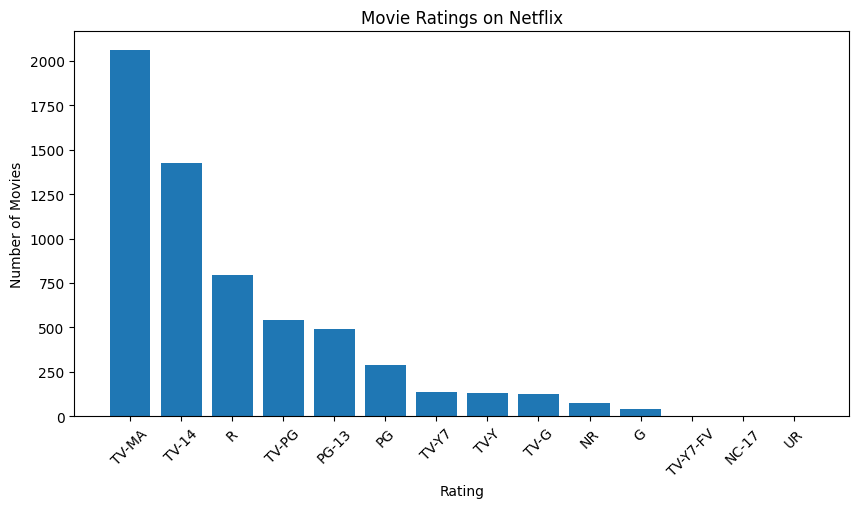

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(movie_ratings.index,
        movie_ratings.values)

plt.title("Movie Ratings on Netflix")

plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

In [ ]:
tv_ratings = tvshows["rating"].value_counts()

print(tv_ratings)

rating
TV-MA       1143
TV-14        730
TV-PG        321
TV-Y7        194
TV-Y         175
TV-G          94
NR             4
R              2
TV-Y7-FV       1
Name: count, dtype: int64


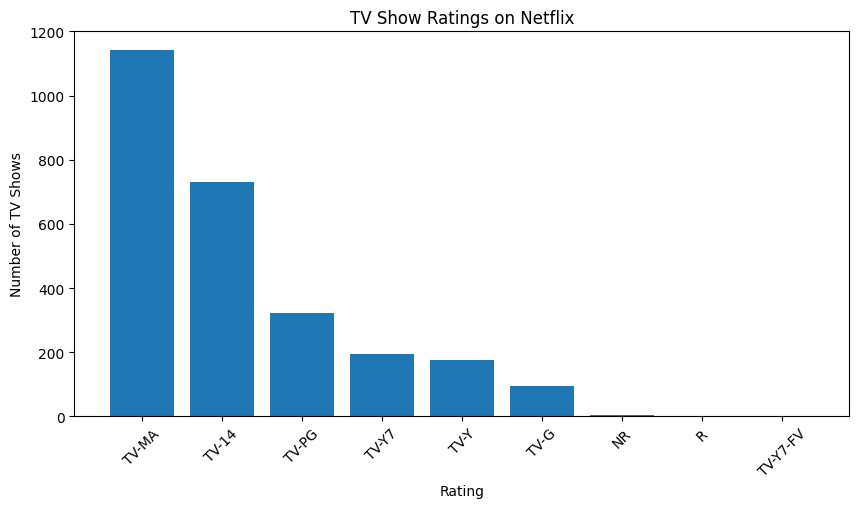

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(tv_ratings.index,
        tv_ratings.values)

plt.title("TV Show Ratings on Netflix")

plt.xlabel("Rating")
plt.ylabel("Number of TV Shows")

plt.xticks(rotation=45)

plt.show()

In [ ]:
comparison = (
    data.groupby(["rating", "type"])
        .size()
        .unstack(fill_value=0)
)

print(comparison)

type      Movie  TV Show
rating                  
G            41        0
NC-17         3        0
NR           75        4
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      730
TV-G        126       94
TV-MA      2062     1143
TV-PG       540      321
TV-Y        131      175
TV-Y7       139      194
TV-Y7-FV      5        1
UR            3        0


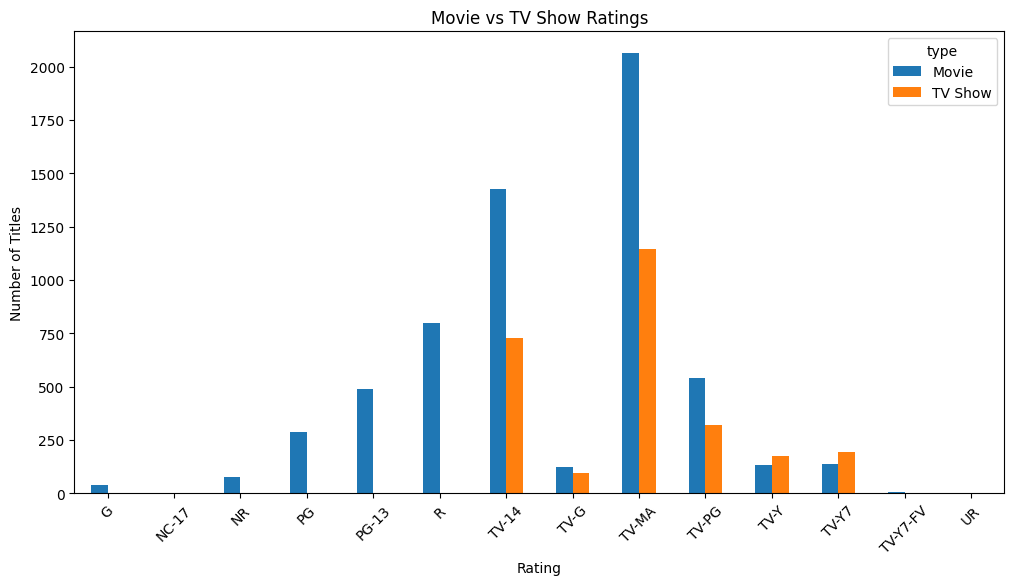

In [ ]:
comparison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Movie vs TV Show Ratings")

plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

# ***Country vs Content Type Analysis***

In [ ]:
country_type = pd.crosstab(data["country"], data["type"])

country_type.head()

type,Movie,TV Show
country,,
Argentina,56,20
Australia,61,53
Austria,8,1
Bangladesh,3,0
Belarus,0,1


In [ ]:
top10 = data["country"].value_counts().head(10).index

country_top10 = country_type.loc[top10]

country_top10

type,Movie,TV Show
country,,
United States,2395,845
India,976,81
United Kingdom,387,251
Pakistan,71,350
Not Given,257,30
Canada,187,84
Japan,87,172
South Korea,49,165
France,148,65


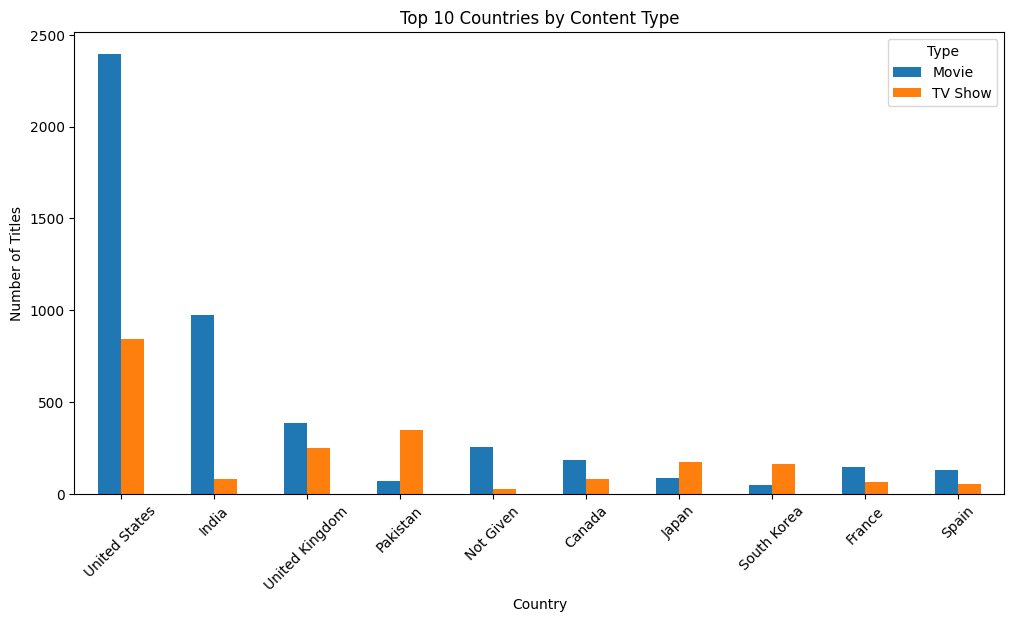

In [ ]:
country_top10.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Countries by Content Type")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.legend(title="Type")

plt.show()

In [ ]:
country_percent = (
    country_type.div(country_type.sum(axis=1), axis=0)
    * 100
)

country_percent.loc[top10]

type,Movie,TV Show
country,,
United States,73.919753,26.080247
India,92.336802,7.663198
United Kingdom,60.658307,39.341693
Pakistan,16.864608,83.135392
Not Given,89.547038,10.452962
Canada,69.003690,30.996310
Japan,33.590734,66.409266
South Korea,22.897196,77.102804
France,69.483568,30.516432


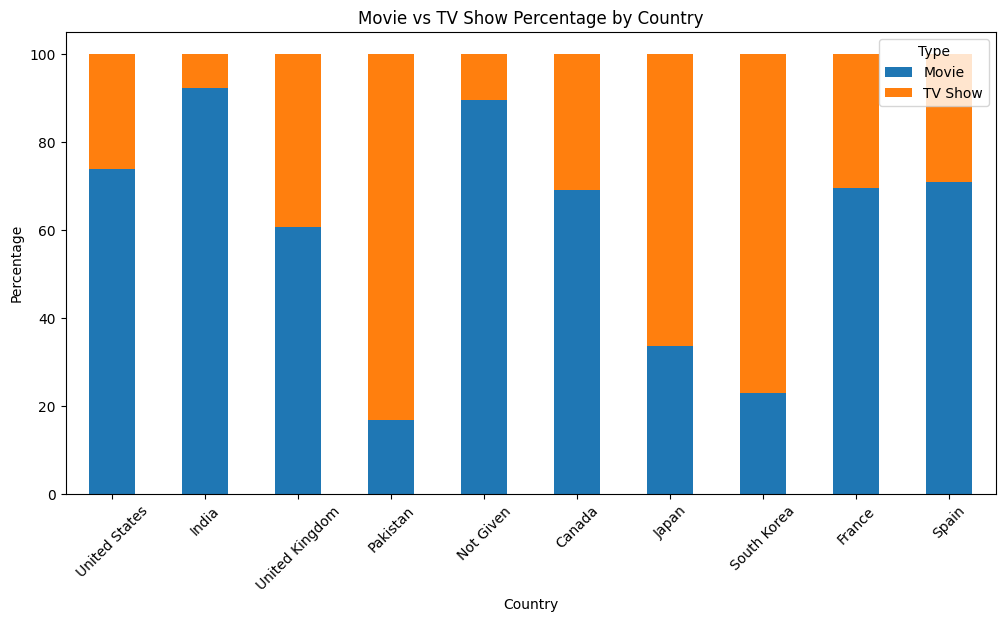

In [ ]:
country_percent.loc[top10].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Movie vs TV Show Percentage by Country")
plt.xlabel("Country")
plt.ylabel("Percentage")

plt.xticks(rotation=45)

plt.legend(title="Type")

plt.show()

# ***Correlation Analysis & Heatmap***

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
 10  year_added    8790 non-null   int32         
 11  month_added   8790 non-null   int32         
 12  day_added     8790 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(8)
memory usage: 789.9+ KB


In [ ]:
numeric_data = data.select_dtypes(include=["int64","int32", "float64"])

numeric_data.head()

,release_year,year_added,month_added,day_added
0,2020,2021,9,25
1,2021,2021,9,24
2,2021,2021,9,24
3,2021,2021,9,22
4,1993,2021,9,24


In [ ]:
correlation = numeric_data.corr()

print(correlation)

              release_year  year_added  month_added  day_added
release_year      1.000000    0.111624     0.152092   0.077625
year_added        0.111624    1.000000    -0.013812  -0.005504
month_added       0.152092   -0.013812     1.000000   0.328499
day_added         0.077625   -0.005504     0.328499   1.000000


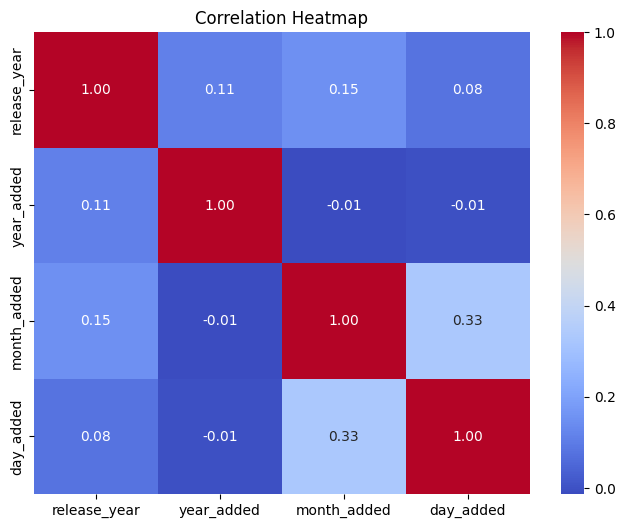

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ***Word Cloud of Movie Titles***

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
movie_titles = data[data["type"] == "Movie"]["title"]
print(movie_titles.head())

0                Dick Johnson Is Dead
3    Confessions of an Invisible Girl
4                             Sankofa
6                        The Starling
7     Motu Patlu in the Game of Zones
Name: title, dtype: object


In [ ]:
text = " ".join(movie_titles)

In [ ]:
from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stopwords
).generate(text)

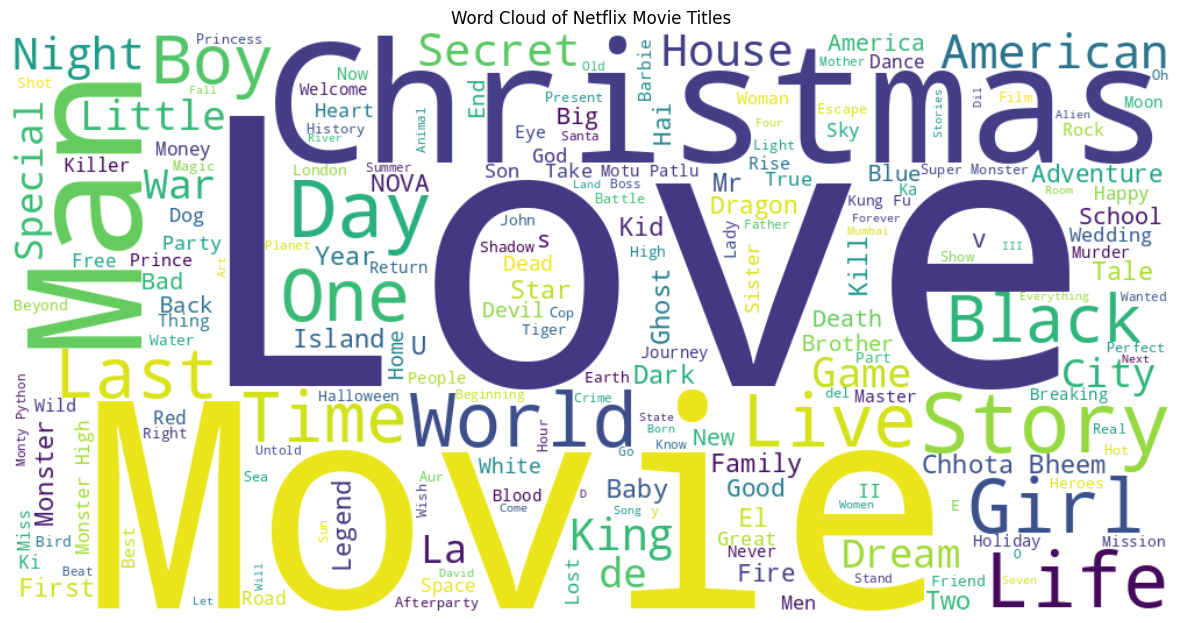

In [ ]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Netflix Movie Titles")

plt.show()

In [ ]:
wordcloud.to_file("movie_wordcloud.png")

# ***Business Insights & Recommendations***